In [1]:
# most code comes from here https://github.com/tbonnair/Dynamical-Regimes-of-Diffusion-Models
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import torch
import sys
import os
from tqdm import tqdm
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from fun import forward, backward, score, classify, plot_speciation_3d
from SASNE import SASNE
from construct_graph import construct_graph

### Toy example

In [2]:
torch.manual_seed(123)
d = 2            # Dimension
nsamples_small_n = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

mu_star = torch.tensor([4.0, 4.0])
std = 1.0

# Start with pure random noise at t=T 
small_n_x_current = torch.randn(d, nsamples_small_n) 


In [3]:
small_n_path_history = []

for t in tqdm(times):
    small_n_path_history.append(small_n_x_current.T.clone().numpy()) 
    small_n_x_current, _ = backward(small_n_x_current, t, dt, mu_star, std)

small_n_path_history = np.array(small_n_path_history)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 15238.83it/s]


Since we can solve the score function analytically, we just need to sample using he backward process
The particles' starting point is the same, the trajectories will remain tangled until the end of the backward process. 
Once speciating takes place, the path commits to a class until the end of the reverse process.
It is at this point that the reverse process starts producing features of the same class. Since we know the exact form of the score function there is not a collapse time.

#### Speciation time $t_s$ - Analytical solution

In [4]:
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
t_s_idx = next(idx for idx, t in enumerate(times) if round(t, 2) == round(t_s, 2))
print(t_s)

1.7482537641375833


In [5]:
# collapse time
# t_c = 1/2 * np.log(1 + std**2/(nsamples_small_n**(2/d) - 1))
# print(t_c)

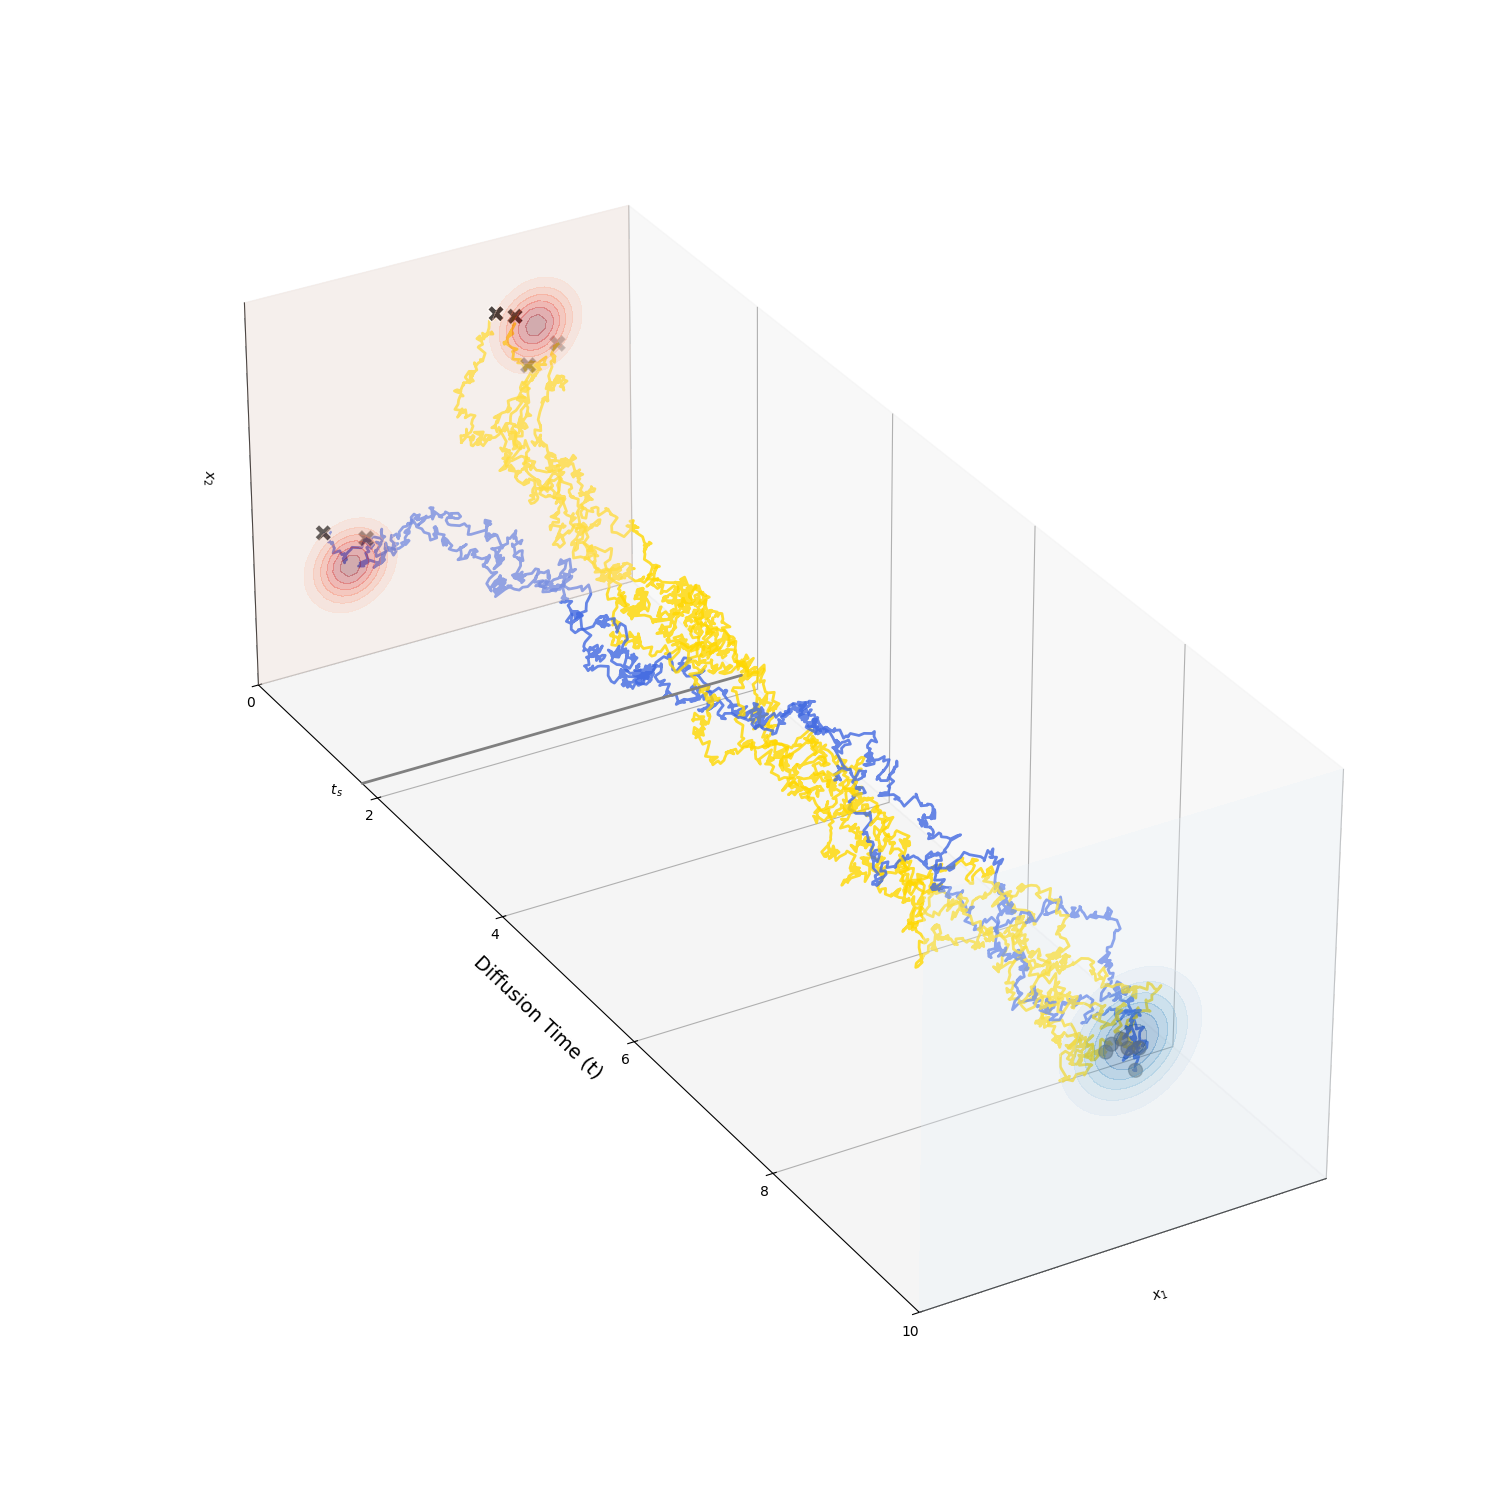

In [6]:
plot_speciation_3d(path_history=small_n_path_history, times=times, mu_star=mu_star, std=std, nsamples=nsamples_small_n, t_s=t_s, t_c=None)

In [8]:
diffusion_steps_idxs = [0,t_s_idx,-1]
W_list = [construct_graph(small_n_path_history[t]) for t in diffusion_steps_idxs]

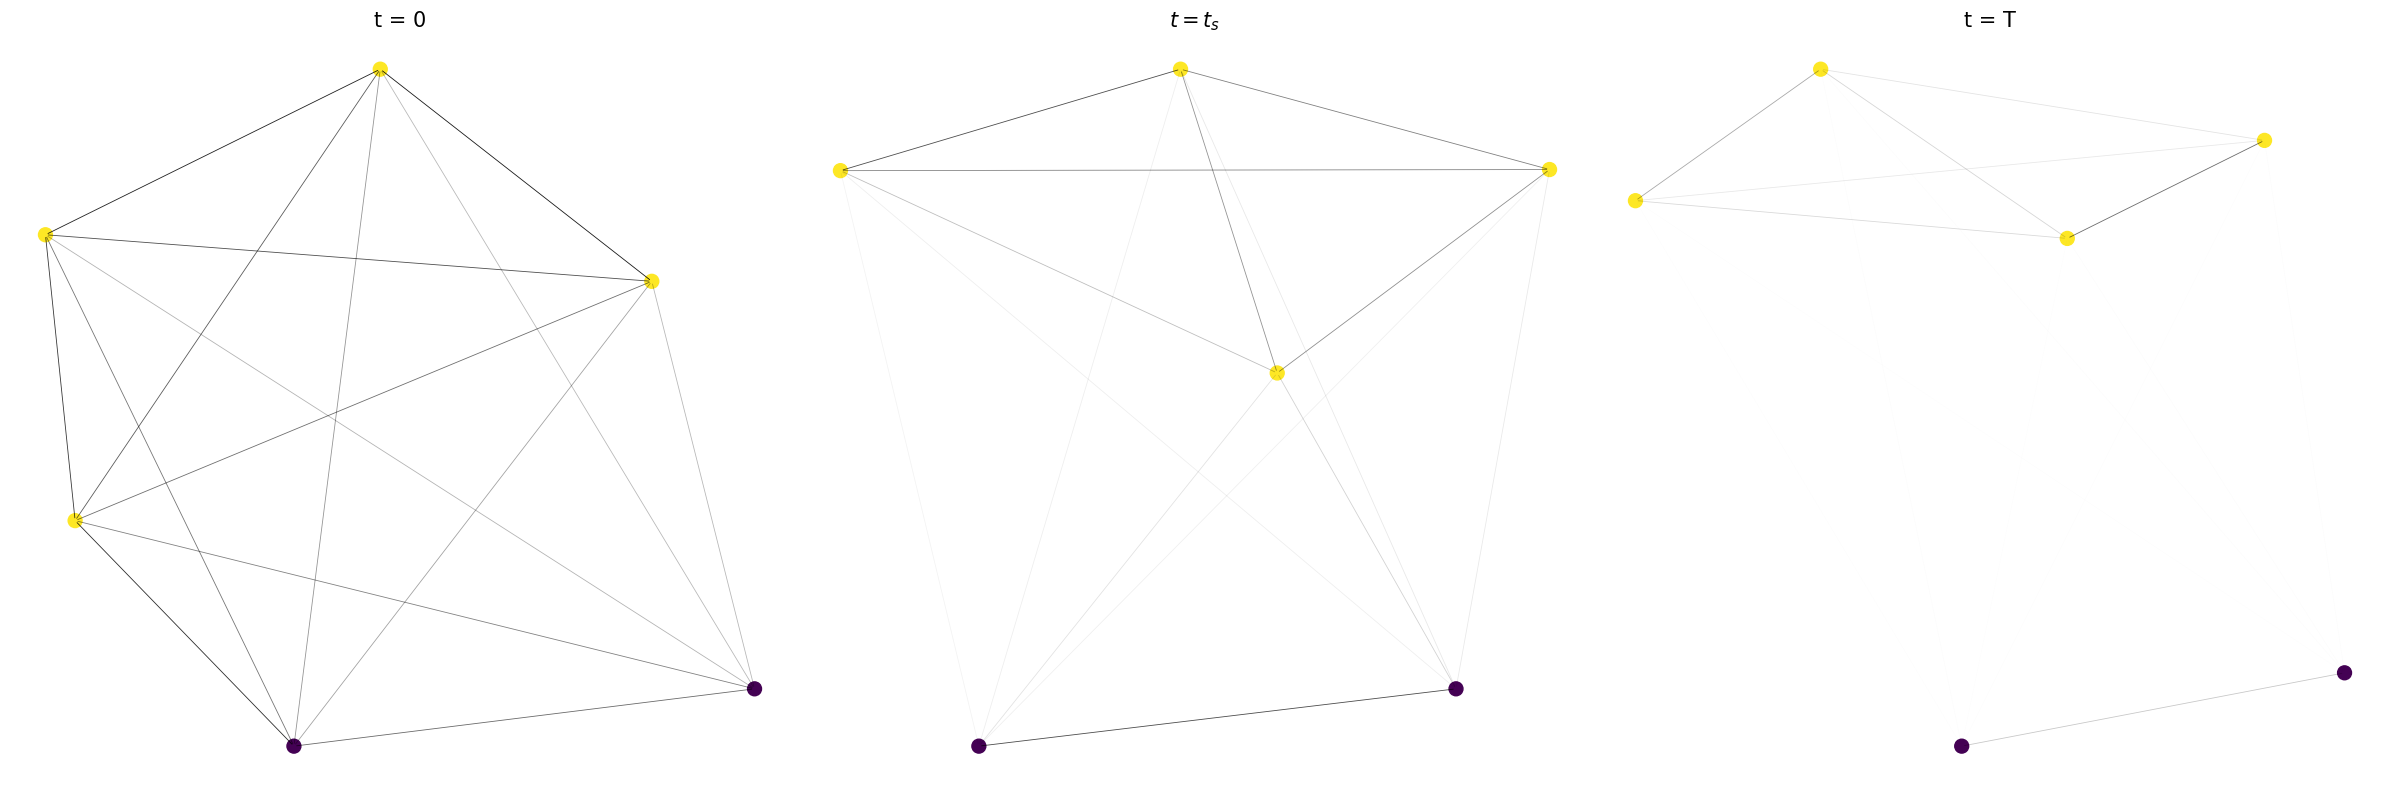

In [10]:
X_T = torch.as_tensor(small_n_path_history[-1], dtype=mu_star.dtype).T
node_labels = classify(X_T, mu_star)
colors = node_labels.numpy().flatten()
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
titles = ["t = 0", "$t = t_s$", "t = T"]
for i, W in enumerate(W_list):
    G = nx.from_numpy_array(W)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    ax = axes[i]
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, ax=ax)
    edges = G.edges(data=True)
    for u, v, d in edges:
        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="-", color="black", alpha=min(max(d['weight'], 0), 1),lw=0.6))
    ax.set_title(titles[i], fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
dim = 2
nsamples_large_n = 1000
T_max = 10.0
dt = 0.01
mu_star, std = torch.tensor([4.0, 4.0]), 1.0
large_n_x_current = torch.randn(dim, nsamples_large_n) 
large_n_path_history = []
for t in tqdm(times):
    large_n_path_history.append(large_n_x_current.T.clone().numpy()) 
    large_n_x_current, _ = backward(large_n_x_current, t, dt, mu_star, std)
large_n_path_history = np.array(large_n_path_history)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 16230.70it/s]


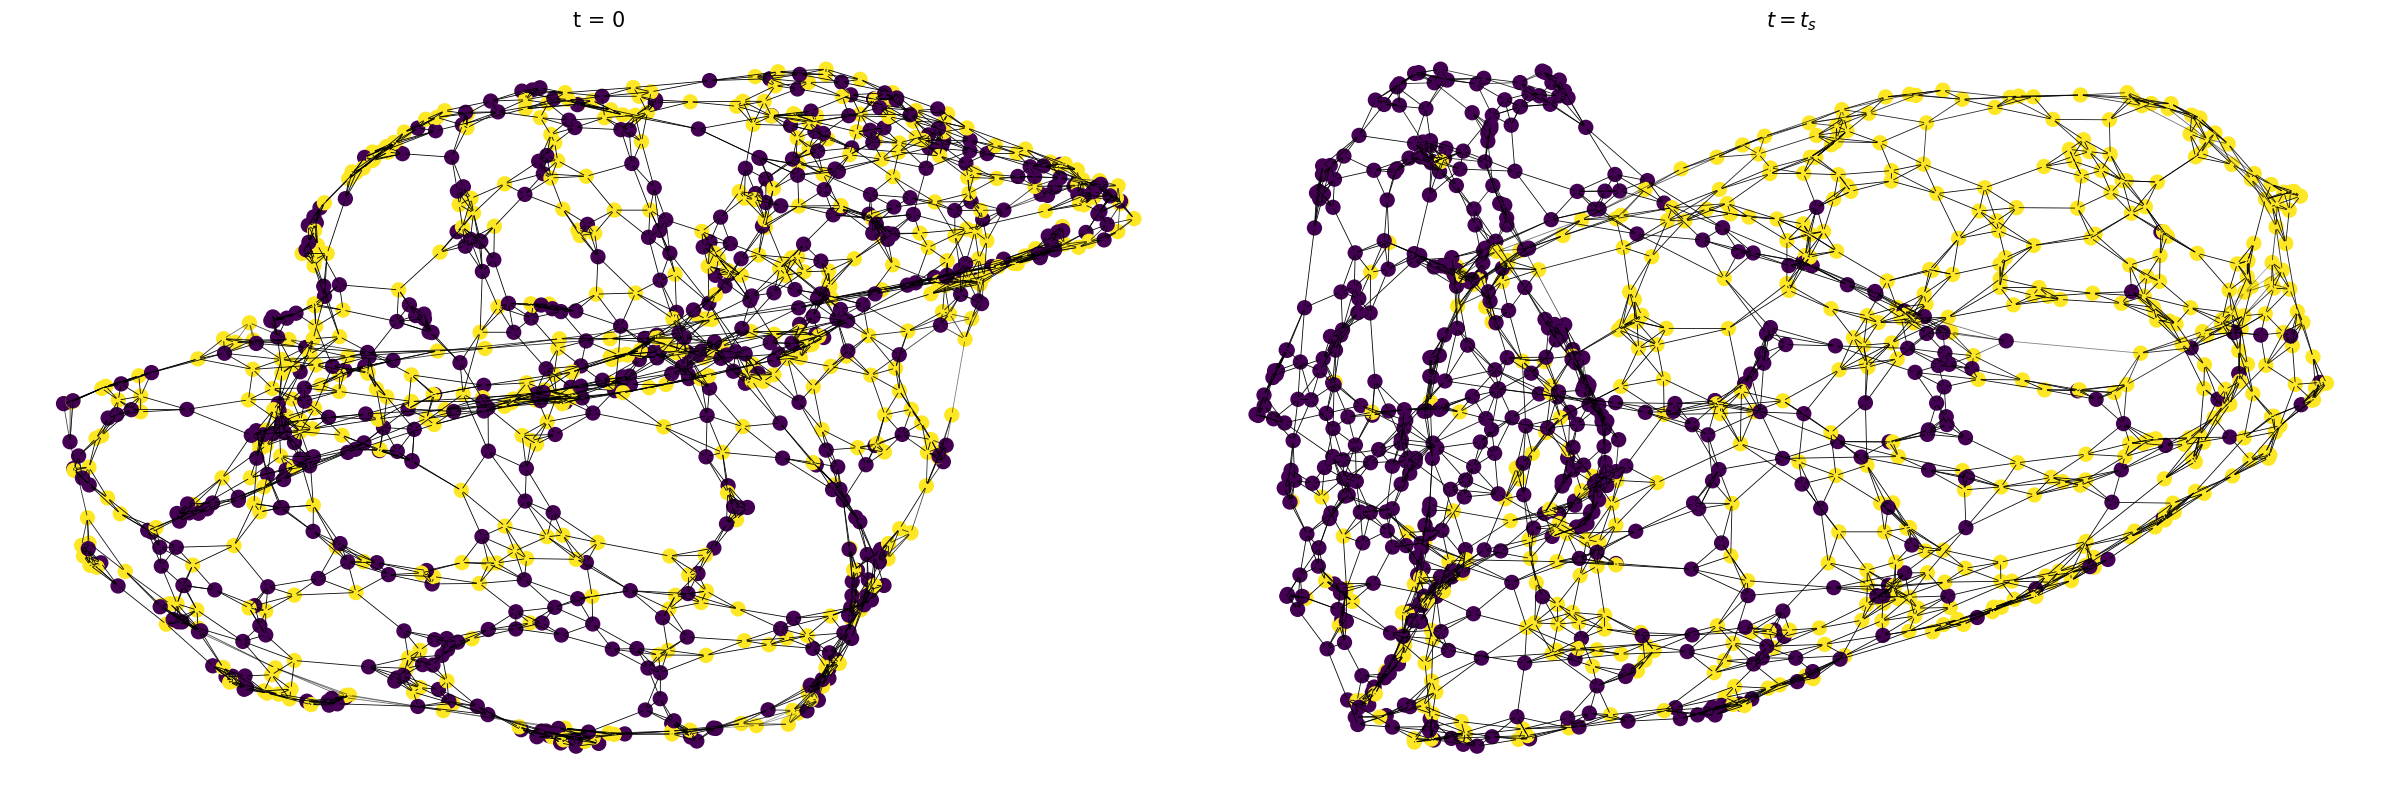

In [25]:
W_list_large_n = [construct_graph(large_n_path_history[t]) for t in [0, t_s_idx]]
X_T = torch.as_tensor(large_n_path_history[-1], dtype=mu_star.dtype).T
node_labels = classify(X_T, mu_star)
colors = node_labels.numpy().flatten()
fig, axes = plt.subplots(1, 2, figsize=(24, 8))
titles = ["t = 0", "$t = t_s$"]
for i, W in enumerate(W_list_large_n):
    G = nx.from_numpy_array(W)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    ax = axes[i]
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, ax=ax)
    edges = G.edges(data=True)
    for u, v, d in edges:
        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="-", color="black", alpha=min(max(d['weight'], 0), 1),lw=0.6))
    ax.set_title(titles[i], fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()